Generated dataset file.
shape: (2600, 10) | defect rate: 0.281
test F1 (depth 4): 0.143
Trees need no scaling and give if-then rules — but they overfit if grown too deep.


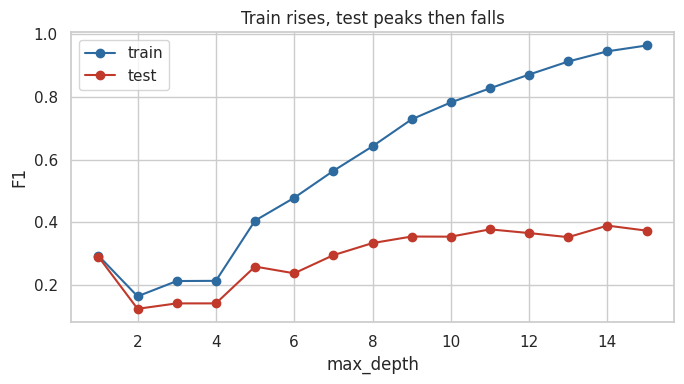

In [ ]:
import os
import numpy as np
import pandas as pd


def build_welds(csv_path="weld_inspection.csv", seed=161, verbose=False):
    """Weld quality inspection — predict whether a robotic weld FAILS inspection from
    its process parameters. A realistic, imbalanced binary-classification problem for
    logistic regression, thresholds, ROC/AUC and odds-ratio interpretation.

    Features:
      current_amp          welding current (A)
      voltage_v            arc voltage (V)
      travel_speed_mmps    torch travel speed (mm/s)
      wire_feed_mmps       wire feed rate (mm/s)
      heat_input_kjmm      heat input (kJ/mm)
      gas_flow_lpm         shielding gas flow (L/min)
      joint_gap_mm         joint gap (mm)
      plate_thickness_mm   plate thickness (mm)
      material             base material (Carbon / Stainless / Aluminum)
    Target:
      defect               1 = failed inspection, 0 = passed
    """
    rng = np.random.default_rng(seed)
    N = 2600
    current = rng.normal(190, 30, N).clip(90, 300)
    voltage = (18 + 0.03 * current + rng.normal(0, 1.2, N)).clip(14, 32)
    travel = rng.normal(8, 2.2, N).clip(3, 16)
    wire = (current * 0.03 + rng.normal(0, 0.6, N)).clip(2, 12)
    heat = (voltage * current / (travel * 1000)).clip(0.2, 4.0)     # kJ/mm
    gas = rng.normal(16, 3, N).clip(6, 28)
    gap = rng.gamma(2.0, 0.35, N).clip(0, 4).round(2)               # right-s
    thick = rng.choice([3, 5, 6, 8, 10, 12, 16], N).astype(float)
    material = rng.choice(["Carbon", "Stainless", "Aluminum"], N, p=[0.55, 0.30, 0.15])
    mat_risk = np.select([material == "Carbon", material == "Stainless", material == "Aluminum"],
                         [0.0, 0.3, 0.8])                            # Aluminum harder to weld

    # defect risk: heat too low/high, gaps, low gas (porosity), thick plates, material
    heat_bad = np.abs(heat - 1.3)
    z = (-3.2
         + 1.6 * heat_bad
         + 1.1 * gap
         + 0.05 * (16 - gas)
         + 0.04 * (thick - 8)
         + 0.012 * (travel - 8) ** 2
         + mat_risk)
    p = 1 / (1 + np.exp(-z))
    defect = (rng.random(N) < p).astype(int)

    df = pd.DataFrame({
        "current_amp": current.round(1), "voltage_v": voltage.round(2),
        "travel_speed_mmps": travel.round(2), "wire_feed_mmps": wire.round(2),
        "heat_input_kjmm": heat.round(3), "gas_flow_lpm": gas.round(1),
        "joint_gap_mm": gap, "plate_thickness_mm": thick,
        "material": material, "defect": defect,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("welds:", df.shape)
        print("defect rate:", round(df.defect.mean(), 3))
        print("defect by material:\n",
              df.groupby("material")["defect"].mean().round(3).to_string())
    return df

if not os.path.exists('weld_inspection.csv'):
    build_welds(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')


import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
df = pd.read_csv('weld_inspection.csv')
y = df['defect']; X = df.drop(columns='defect')
num = X.select_dtypes('number').columns.tolist(); cat = ['material']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(drop='first'), cat)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print('shape:', df.shape, '| defect rate:', round(y.mean(), 3))
df.head(3)
# -----------------------------------------------------------
# ▸ 1A. A SINGLE DECISION TREE
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
tree = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=4, random_state=0))])
tree.fit(X_train, y_train)
print('test F1 (depth 4):', round(f1_score(y_test, tree.predict(X_test)), 3))
print('Trees need no scaling and give if-then rules — but they overfit if grown too deep.')


# -----------------------------------------------------------
# ▸ 1B. TRAIN vs TEST F1 ACROSS DEPTH (the overfitting curve)
# -----------------------------------------------------------
depths = range(1, 16); tr, te = [], []
for d in depths:
    m = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=d, random_state=0))]).fit(X_train, y_train)
    tr.append(f1_score(y_train, m.predict(X_train)))
    te.append(f1_score(y_test, m.predict(X_test)))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(depths), tr, 'o-', label='train', color='#2D6A9F')
ax.plot(list(depths), te, 'o-', label='test', color='#C0392B')
ax.set_xlabel('max_depth'); ax.set_ylabel('F1'); ax.set_title('Train rises, test peaks then falls')
ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline

# 1. Find the depth with the highest test F1
best_depth = depths[te.index(max(te))]
print("Best max_depth:", best_depth)

# 2. Refit the Decision Tree using the best depth
best_tree = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=best_depth, random_state=42))])
best_tree.fit(X_train, y_train)

# 3. Predict and print the test F1 score
y_pred = best_tree.predict(X_test)
print("Test F1 Score:", f1_score(y_test, y_pred))

Best max_depth: 14
Test F1 Score: 0.39452054794520547


In [ ]:
# -----------------------------------------------------------
# 🔹 2A. RANDOM FOREST vs GRADIENT BOOSTING vs ONE TREE
# -----------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
def evaluate(model):
    pipe = Pipeline([('prep', pre), ('clf', model)]).fit(X_train, y_train)
    pred = pipe.predict(X_test); proba = pipe.predict_proba(X_test)[:, 1]
    return f1_score(y_test, pred), roc_auc_score(y_test, proba)
for name, m in [('DecisionTree', DecisionTreeClassifier(max_depth=4, random_state=0)),
                ('RandomForest', RandomForestClassifier(n_estimators=300, random_state=0)),
                ('GradientBoosting', GradientBoostingClassifier(random_state=0))]:
    f1, auc = evaluate(m)
    print(f'{name:18s} F1: {f1:.3f} | ROC-AUC: {auc:.3f}')


DecisionTree       F1: 0.143 | ROC-AUC: 0.625
RandomForest       F1: 0.312 | ROC-AUC: 0.666
GradientBoosting   F1: 0.291 | ROC-AUC: 0.663


In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline

# Train Random Forest (Bagging)
rf_pipe = Pipeline([('prep', pre), ('clf', RandomForestClassifier(random_state=42))])
rf_pipe.fit(X_train, y_train)

# Train Gradient Boosting (Boosting)
gb_pipe = Pipeline([('prep', pre), ('clf', GradientBoostingClassifier(random_state=42))])
gb_pipe.fit(X_train, y_train)

# Predict probabilities
rf_probs = rf_pipe.predict_proba(X_test)[:, 1]
gb_probs = gb_pipe.predict_proba(X_test)[:, 1]

# Compute ROC-AUC
rf_auc = roc_auc_score(y_test, rf_probs)
gb_auc = roc_auc_score(y_test, gb_probs)

print("Random Forest ROC-AUC :", round(rf_auc, 4))
print("Gradient Boosting ROC-AUC :", round(gb_auc, 4))

# Determine the winner
if rf_auc > gb_auc:
    print("Winner: Random Forest")
elif gb_auc > rf_auc:
    print("Winner: Gradient Boosting")
else:
    print("Both models have the same ROC-AUC")

Random Forest ROC-AUC : 0.6629
Gradient Boosting ROC-AUC : 0.6632
Winner: Gradient Boosting


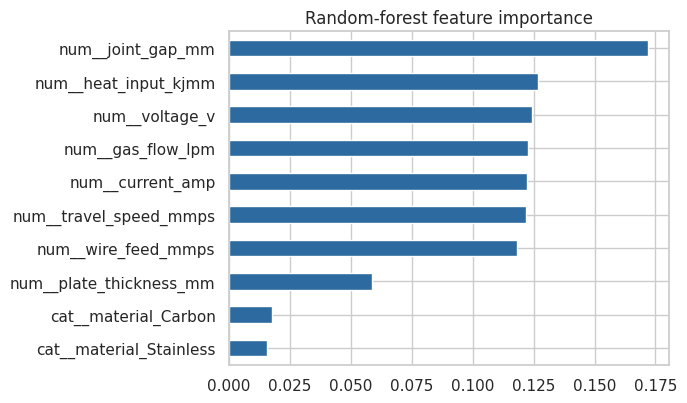

Top drivers:
num__joint_gap_mm       0.172
num__heat_input_kjmm    0.127
num__voltage_v          0.124
num__gas_flow_lpm       0.123


In [ ]:

# -----------------------------------------------------------
# 🔹 3A. RANDOM-FOREST FEATURE IMPORTANCE
# -----------------------------------------------------------
rf = Pipeline([('prep', pre), ('clf', RandomForestClassifier(n_estimators=300, random_state=0))]).fit(X_train, y_train)
feat_names = rf.named_steps['prep'].get_feature_names_out()
imp = pd.Series(rf.named_steps['clf'].feature_importances_, index=feat_names).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.2))
imp.plot(kind='barh', color='#2D6A9F', ax=ax); ax.set_title('Random-forest feature importance')
plt.tight_layout(); plt.show()
print('Top drivers:'); print(imp.sort_values(ascending=False).head(4).round(3).to_string())


Top Features by Permutation Importance:
              Feature  Importance
6        joint_gap_mm    0.085877
2   travel_speed_mmps    0.033669
8            material    0.017131
4     heat_input_kjmm    0.015997
7  plate_thickness_mm    0.009622
1           voltage_v   -0.000143
0         current_amp   -0.007172
3      wire_feed_mmps   -0.008039
5        gas_flow_lpm   -0.016749


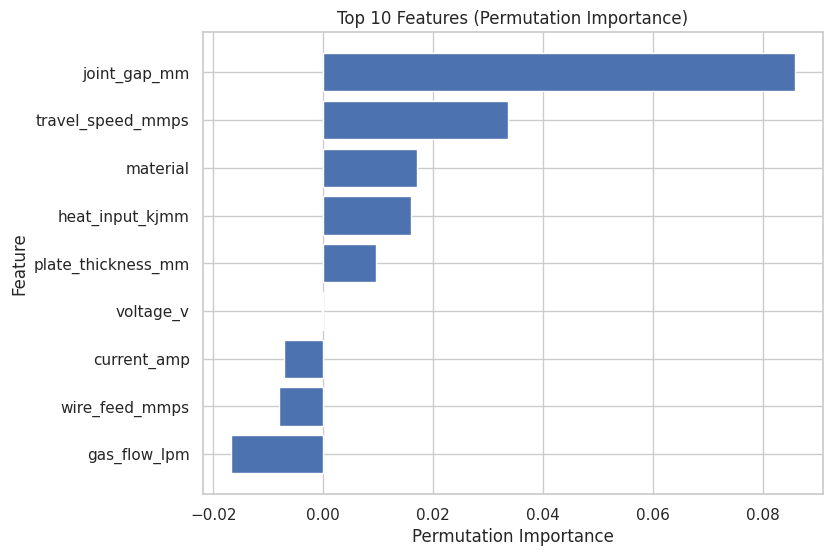

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# 1. Compute permutation importance on the test set
perm_importance = permutation_importance(
    rf,
    X_test,
    y_test,
    scoring='f1',
    n_repeats=10,
    random_state=42
)

# 2. Create a DataFrame of feature importances
perm_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': perm_importance.importances_mean
})

# Sort by importance
perm_df = perm_df.sort_values(by='Importance', ascending=False)

# Print the top features
print("Top Features by Permutation Importance:")
print(perm_df.head(10))

# Plot the top 10 features
plt.figure(figsize=(8,6))
plt.barh(perm_df['Feature'].head(10), perm_df['Importance'].head(10))
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features (Permutation Importance)")
plt.show()


In [ ]:
# -----------------------------------------------------------
# 🔹 4A. GRID-SEARCH GRADIENT BOOSTING ON F1
# -----------------------------------------------------------
from sklearn.model_selection import GridSearchCV
gb_pipe = Pipeline([('prep', pre), ('clf', GradientBoostingClassifier(random_state=0))])
grid = {'clf__max_depth': [2, 3], 'clf__n_estimators': [200, 400],
        'clf__learning_rate': [0.05, 0.1]}
gs = GridSearchCV(gb_pipe, grid, cv=4, scoring='f1', n_jobs=-1).fit(X_train, y_train)
print('best params:', gs.best_params_)
print('best CV F1:', round(gs.best_score_, 3))
best = gs.best_estimator_
print('tuned test F1:', round(f1_score(y_test, best.predict(X_test)), 3))


best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 400}
best CV F1: 0.33
tuned test F1: 0.347


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline # Import Pipeline

# 1. Grid search with ROC-AUC as the scoring metric
param_grid = {
    'clf__max_depth': [3, 5, 7, 10, None], # Updated for pipeline
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4]
}

# Create a pipeline that includes preprocessing and the classifier
pipeline_estimator = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(random_state=42))])

grid = GridSearchCV(
    estimator=pipeline_estimator, # Use the pipeline as the estimator
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation ROC-AUC:", round(grid.best_score_, 4))

# Evaluate on the test set
from sklearn.metrics import roc_auc_score

y_prob = grid.best_estimator_.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_prob)

print("Test ROC-AUC:", round(test_auc, 4))

Best Parameters: {'clf__max_depth': 5, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10}
Best Cross-Validation ROC-AUC: 0.608
Test ROC-AUC: 0.628


In [ ]:

# -----------------------------------------------------------
# 🔹 5A. class_weight + THRESHOLD TUNING
# -----------------------------------------------------------
from sklearn.metrics import precision_score, recall_score
rf_bal = Pipeline([('prep', pre), ('clf', RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=0))]).fit(X_train, y_train)
proba = rf_bal.predict_proba(X_test)[:, 1]
for t in [0.3, 0.4, 0.5, 0.6]:
    pred = (proba >= t).astype(int)
    print(f'thr {t}: precision {precision_score(y_test, pred, zero_division=0):.3f} | recall {recall_score(y_test, pred):.3f} | F1 {f1_score(y_test, pred):.3f}')


thr 0.3: precision 0.398 | recall 0.557 | F1 0.465
thr 0.4: precision 0.500 | recall 0.317 | F1 0.388
thr 0.5: precision 0.536 | recall 0.164 | F1 0.251
thr 0.6: precision 0.593 | recall 0.087 | F1 0.152


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score
from sklearn.pipeline import Pipeline as SKPipeline # Import sklearn's Pipeline for balanced_tree

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline # Use ImbPipeline for imblearn's Pipeline

    print("imbalanced-learn available — building an SMOTE pipeline...")

    # SMOTE + Decision Tree Pipeline
    smote_pipeline = ImbPipeline([
        ('prep', pre), # Add the preprocessor
        ('smote', SMOTE(random_state=42)),
        ('tree', DecisionTreeClassifier(random_state=42))
    ])

    # Train the pipeline
    smote_pipeline.fit(X_train, y_train)

    # Predict and evaluate recall
    y_pred_smote = smote_pipeline.predict(X_test)
    smote_recall = recall_score(y_test, y_pred_smote)

    print("SMOTE Pipeline Recall:", round(smote_recall, 4))

    # Compare with class_weight='balanced'
    # Wrap balanced_tree in a sklearn Pipeline to apply preprocessing
    balanced_tree_pipe = SKPipeline([
        ('prep', pre),
        ('tree', DecisionTreeClassifier(
            class_weight='balanced',
            random_state=42
        ))
    ])

    balanced_tree_pipe.fit(X_train, y_train)
    y_pred_balanced = balanced_tree_pipe.predict(X_test)
    balanced_recall = recall_score(y_test, y_pred_balanced)

    print("Class_weight='balanced' Recall:", round(balanced_recall, 4))

    if smote_recall > balanced_recall:
        print("SMOTE achieved higher recall.")
    elif balanced_recall > smote_recall:
        print("class_weight='balanced' achieved higher recall.")
    else:
        print("Both methods achieved the same recall.")

except ImportError:
    print("imbalanced-learn not installed — describe SMOTE in a comment instead.")

imbalanced-learn available — building an SMOTE pipeline...
SMOTE Pipeline Recall: 0.377
Class_weight='balanced' Recall: 0.306
SMOTE achieved higher recall.
